# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     | Alan Yael Almaraz Parra  |
| **Fecha**      | 08/03/2026  |
| **Expediente** | 751171  | 

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [117]:
import pandas as pd

In [118]:
obj = pd.read_csv('Default.csv')

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [119]:
obj.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [120]:
obj.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

Columnas númericas 

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [121]:
obj['default'] = obj['default'].astype("category")

In [122]:
obj['student'] = obj['student'].astype("category")

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

<Axes: title={'center': 'balance'}, xlabel='default'>

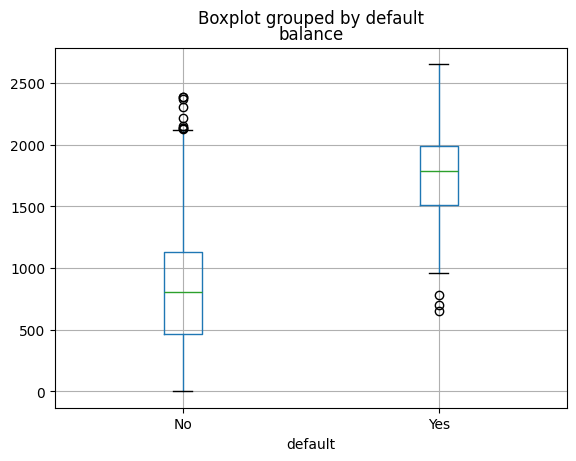

In [123]:
obj.boxplot(column='balance', by='default')

<Axes: title={'center': 'income'}, xlabel='default'>

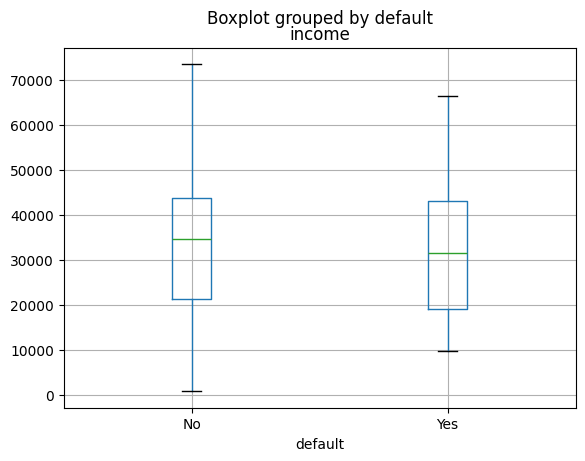

In [124]:
obj.boxplot(column='income', by='default')

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

<Axes: xlabel='balance', ylabel='income'>

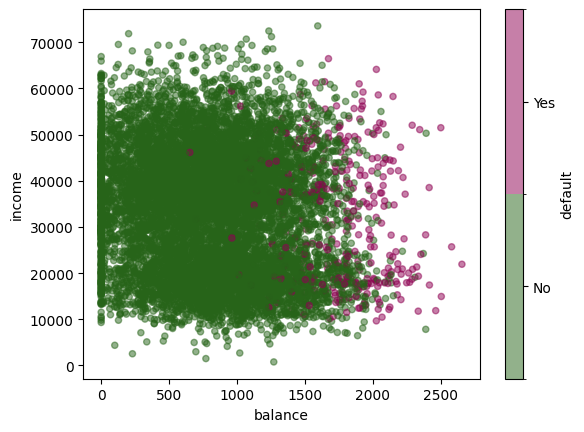

In [125]:
obj.plot.scatter(x='balance', y='income', c='default', colormap='PiYG_r', alpha=0.5)

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [126]:
y = obj['default'] == 'Yes'

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\plotting\_matplotlib\core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


<Axes: xlabel='balance', ylabel='default'>

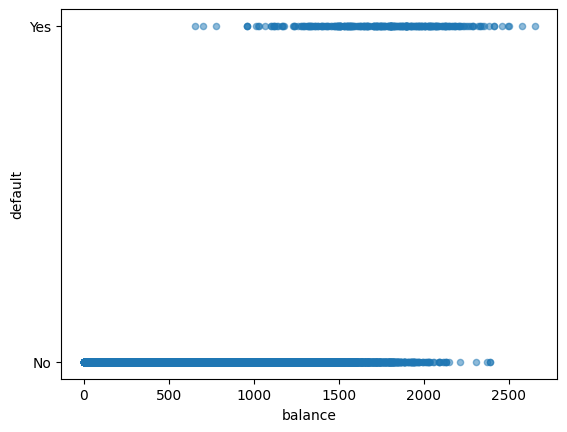

In [127]:
obj.plot.scatter(x='balance', y='default', colormap='PiYG_r', alpha=0.5)

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [128]:
from sklearn.linear_model import LogisticRegression

In [129]:
lr = LogisticRegression()
X = obj[['balance', 'income']]
lr.fit(X, y)
print("Coefficients:", lr.coef_)
print("Intercept:", lr.intercept_)

Coefficients: [[5.64710265e-03 2.08089741e-05]]
Intercept: [-11.54046792]


In [130]:
import statsmodels.api as sm
X2 = sm.add_constant(X)
model = sm.Logit(y, X2)
results = model.fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.078948
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Sun, 08 Mar 2026   Pseudo R-squ.:                  0.4594
Time:                        19:48:00   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.000     -12.393     -10.688
balance        0.0056      0.000     24.835      0.000       0.005       0.006
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
==============================================================================

Possibly complete quasi-separation: A fraction 0.14 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [131]:
# Nos entrega una matriz de probabilidades para cada clase (0 y 1)
prob = lr.predict_proba(X)

print(prob)

[[9.98495272e-01 1.50472839e-03]
 [9.98738070e-01 1.26193028e-03]
 [9.91973788e-01 8.02621184e-03]
 ...
 [9.96112839e-01 3.88716143e-03]
 [8.71810911e-01 1.28189089e-01]
 [9.99957029e-01 4.29711344e-05]]


2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [132]:
# 1. Extraemos solo la segunda columna
p = prob[:, 1]

# 2. Calculamos la incertidumbre p * (1 - p)
incertidumbre = p * (1 - p)

# 3. Vemos como son los primeros resultados
print(incertidumbre[:5])

[0.00150246 0.00126034 0.00796179 0.00040583 0.00182339]


3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [133]:
import numpy as np
V = np.diagflat(p * (1 - p))

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [134]:
cov = np.linalg.inv(X2.T @ V @ X2)

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [135]:
se = np.sqrt(np.diag(cov))

Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [141]:
# Unimos el intercepto y los coeficientes en un solo array de betas
betas = np.concatenate(([lr.intercept_[0]], lr.coef_[0]))

# Calculamos el estadístico z
z = betas / se

print(z)

[-26.54369673  24.8353795    4.17411232]


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [137]:
from scipy.stats import norm

In [ ]:
p_value = 2 * (1 - norm.cdf(np.abs(z)))
print(p_value)

[0.00000000e+00 0.00000000e+00 2.99150146e-05]


¿Es significativa la relación de los factores con la variable de respuesta?

Las tres variables son altamente significativa con la variable de respuesta.

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [142]:
y2 = obj['student'] == 'Yes'
lr = LogisticRegression()
X_1 = obj[['balance', 'income']]
lr.fit(X_1, y2)
print("Coefficients:", lr.coef_)
print("Intercept:", lr.intercept_)

Coefficients: [[ 0.0009473  -0.00039312]]
Intercept: [8.56941767]


In [143]:
# Nos entrega una matriz de probabilidades para cada clase (0 y 1)
prob = lr.predict_proba(X_1)

# Extraemos solo la segunda columna
p = prob[:, 1]

# Calculamos la incertidumbre p * (1 - p)
incertidumbre = p * (1 - p)

# Vemos como son los primeros resultados
print(incertidumbre[:5])

[0.00028029 0.01000532 0.04934336 0.00687801 0.00298766]


In [144]:
X_2 = sm.add_constant(X_1)
V_1 = np.diagflat(p * (1 - p))
cov = np.linalg.inv(X_2.T @ V_1 @ X_2)
se = np.sqrt(np.diag(cov))

In [145]:
# Unimos el intercepto y los coeficientes en un solo array de betas
betas = np.concatenate(([lr.intercept_[0]], lr.coef_[0]))

# Calculamos el estadístico z
z = betas / se

print(z)

[ 36.28617954   9.93738589 -40.82014306]


In [146]:
p_value = 2 * (1 - norm.cdf(np.abs(z)))
print(p_value)

[0. 0. 0.]


## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [149]:
obj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   default  10000 non-null  category
 1   student  10000 non-null  category
 2   balance  10000 non-null  float64 
 3   income   10000 non-null  float64 
dtypes: category(2), float64(2)
memory usage: 176.2 KB


In [152]:
# Convertir 'student' a numérico (Yes=1, No=0)
obj['student_n'] = obj['student'].map({'Yes': 1, 'No': 0})

# Convertir 'default' a numérico (Yes=1, No=0)
obj['default_n'] = obj['default'].map({'Yes': 1, 'No': 0})

A = obj[['balance', 'income', 'student_n']]
b = obj['default_n']

lr = LogisticRegression()
lr.fit(A, b)

# Nos entrega una matriz de probabilidades para cada clase (0 y 1)
prob = lr.predict_proba(A)

# Extraemos solo la segunda columna
p = prob[:, 1]

# Calculamos la incertidumbre p * (1 - p)
incertidumbre = p * (1 - p)

#Calculamos la matriz de covarianza y los errores estándar
A_2 = sm.add_constant(A)
V_3 = np.diagflat(p * (1 - p))
cov = np.linalg.inv(A_2.T @ V_3 @ A_2)
se = np.sqrt(np.diag(cov))

# Unimos el intercepto y los coeficientes en un solo array de betas
betas = np.concatenate(([lr.intercept_[0]], lr.coef_[0]))

# Calculamos el estadístico z
z = betas / se

#Calculamos el P_value
p_value = 2 * (1 - norm.cdf(np.abs(z)))
print("Z-values:", z)
print("P-values:", p_value)



Z-values: [-22.10609491  24.73550126   0.48262627  -2.59132379]
P-values: [0.         0.         0.62936113 0.00956075]


¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

En el draft de la NBA, cuando se escoje los jugadores se estima si van a ser valiosos para el equipo. Un Falso positivo sería contratarlo en tu elección más cercana y darle un contrato por millones de dolares y términa siendo una farsa que no hace nada para el equipo.

En el Trading el modelo indica que hay una inversión que te va a dejar mucho dinero. Sin embargo el mercado se mueve en contra pierdes dinero. 

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

En una prueba de embarazo, el falso negativo te aparece que no estás embarazada, pero en realidad si lo estarías

En la epoca de covid, te dice que no tienes covid, por lo tanto eres más propenso a morirte porque no tomas el medicamento adecuado ni las precauciones debidas.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3